Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 6043 images belonging to 2 classes.
Found 1510 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


189/189 ━━━━━━━━━━━━━━━━━━━━ 315s 1s/step - accuracy: 0.8332 - loss: 0.3759 - val_accuracy: 0.9099 - val_loss: 0.2499
Epoch 2/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 263s 1s/step - accuracy: 0.8991 - loss: 0.2408 - val_accuracy: 0.9371 - val_loss: 0.1716
Epoch 3/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 263s 1s/step - accuracy: 0.9265 - loss: 0.1866 - val_accuracy: 0.9457 - val_loss: 0.1878
Epoch 4/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 263s 1s/step - accuracy: 0.9418 - loss: 0.1610 - val_accuracy: 0.9576 - val_loss: 0.1372
Epoch 5/5
189/189 ━━━━━━━━━━━━━━━━━━━━ 261s 1s/step - accuracy: 0.9570 - loss: 0.1221 - val_accuracy: 0.9510 - val_loss: 0.1567
48/48 ━━━━━━━━━━━━━━━━━━━━ 20s 422ms/step - accuracy: 0.9510 - loss: 0.1567
Validation Accuracy: 0.9509933590888977
Validation Loss: 0.15674686431884766


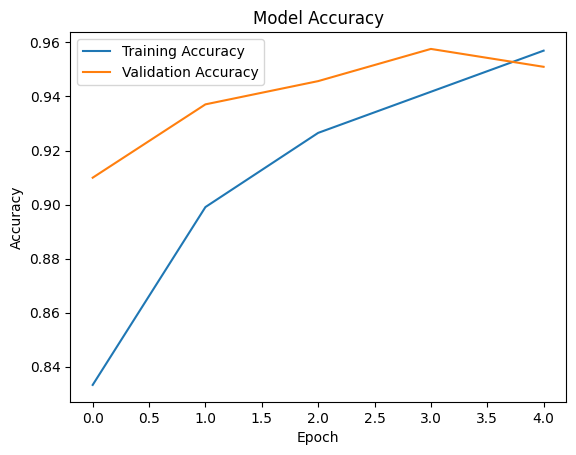

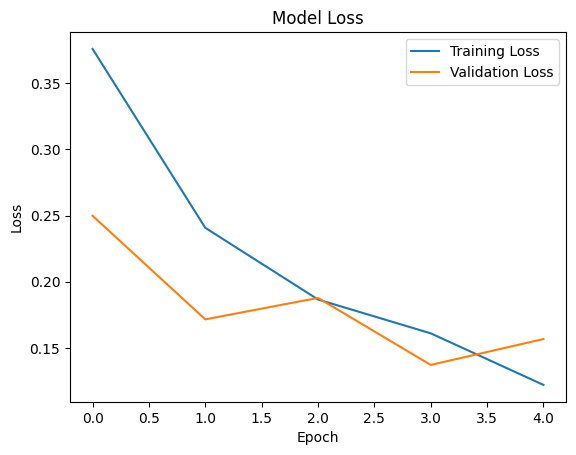

48/48 ━━━━━━━━━━━━━━━━━━━━ 23s 473ms/step


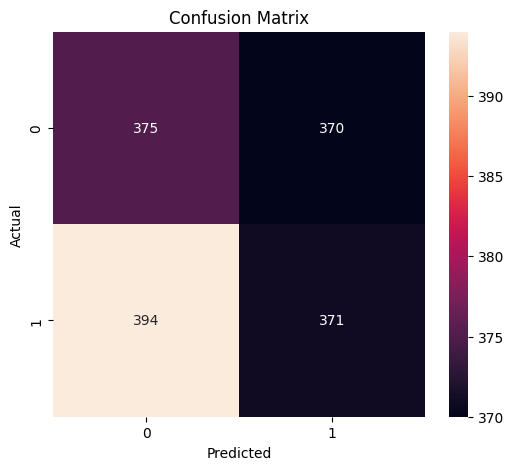

              precision    recall  f1-score   support

           0       0.49      0.50      0.50       745
           1       0.50      0.48      0.49       765

    accuracy                           0.49      1510
   macro avg       0.49      0.49      0.49      1510
weighted avg       0.49      0.49      0.49      1510

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
Prediction: With Mask


In [2]:
from google.colab import drive
drive.mount('/content/drive')
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import seaborn as sns
dataset_path = "/content/drive/MyDrive/internship_csv_files/Face Mask Dataset"
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(
    128,
    activation='relu'
))

model.add(Dropout(0.5))

model.add(Dense(
    1,
    activation='sigmoid'
))
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5
)
loss, accuracy = model.evaluate(validation_generator)

print("Validation Accuracy:", accuracy)
print("Validation Loss:", loss)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend([
    'Training Accuracy',
    'Validation Accuracy'
])

plt.show()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend([
    'Training Loss',
    'Validation Loss'
])

plt.show()
predictions = model.predict(validation_generator)

y_pred = (predictions > 0.5).astype(int)

cm = confusion_matrix(
    validation_generator.classes,
    y_pred[:len(validation_generator.classes)]
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()
print(
    classification_report(
        validation_generator.classes,
        y_pred[:len(validation_generator.classes)]
    )
)
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "/content/drive/MyDrive/internship_csv_files/test.jpg"

img = image.load_img(
    img_path,
    target_size=(128,128)
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Prediction: Without Mask")
else:
    print("Prediction: With Mask")